In [1]:
# Data source: https://history.house.gov/Exhibitions-and-Publications/BAIC/Historical-Data/Black-American-Representatives-and-Senators-by-Congress/

# Copied and lightly processed in Google Sheets and exported as a .csv

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("./us_black_congress.csv")

In [10]:
df

,Congress,Name,State or Territory,Party,House/Senate\nService,South,Session No
0,41st (1869-1871),"LONG, Jefferson Franklin 1",GA,Republican,House,True,41
1,41st (1869-1871),"RAINEY, Joseph Hayne 2",SC,Republican,House,True,41
2,41st (1869-1871),"REVELS, Hiram Rhodes 3",MS,Republican,Senate,True,41
3,42nd (1871-1873),"DE LARGE, Robert Carlos 4",SC,Republican,House,True,42
4,42nd (1871-1873),"ELLIOTT, Robert Brown",SC,Republican,House,True,42
...,...,...,...,...,...,...,...
1112,119th (2025-2027),"DONALDS, Byron",FL,Republican,House,True,119
1111,119th (2025-2027),"DAVIS, Don",NC,Democrat,House,True,119
1110,119th (2025-2027),"DAVIS, Danny K.",IL,Democrat,House,False,119
1116,119th (2025-2027),"FIGURES, Shomari C.",AL,Democrat,House,True,119


In [4]:
df["South"] = False

In [5]:
south = ['AL', 'AR', 'DE', 'FL', 'GA', 'KY', 'LA', 'MD', 'MS', 'NC', 'OK', 'SC', 'TN', 'TX', 'VA', 'WV']

df["South"] = df["State or Territory"].isin(south)

In [6]:
df["Session No"] = (
    df["Congress"].str.extract(r"(\d+)").astype(int)
)

df = df.sort_values(by="Session No")

In [33]:
df_summary = df.groupby(["Session No", "South","House/Senate\nService"]).agg(
    no=("Name", "count")
)

In [39]:
all_congress = list(range(41, 120))
all_south = [False, True]
all_house_senate = ["House", "Senate"]

full_index = pd.MultiIndex.from_product(
    [all_congress, all_south, all_house_senate], names=["Session No", "South", "House/Senate"]
)

In [40]:
df_summary = df_summary.reindex(full_index, fill_value=0).reset_index()

In [42]:
house_only = df_summary[df_summary["House/Senate"]=="House"]

In [43]:
south_reps = house_only[house_only["South"]==True]
non_south_reps = house_only[house_only["South"]==False]

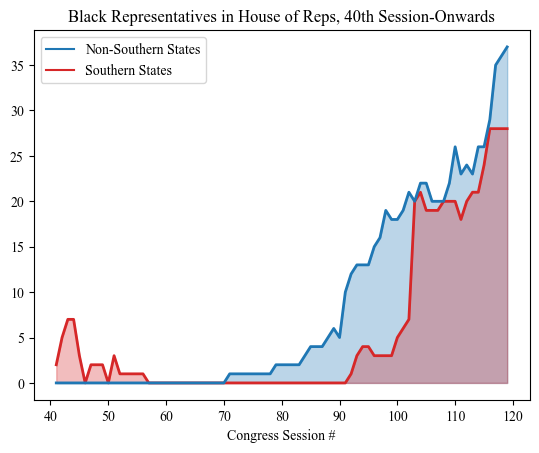

In [44]:
plt.rcParams['font.family'] = 'Times New Roman'
plt.plot(south_reps["Session No"], south_reps["no"], color='tab:red', linestyle='-', marker='', linewidth=2)
plt.plot(non_south_reps["Session No"], non_south_reps["no"], color='tab:blue', linestyle='-', marker='', linewidth=2)
plt.fill_between(non_south_reps["Session No"], non_south_reps["no"], color="tab:blue", alpha=0.3)
plt.fill_between(south_reps["Session No"], south_reps["no"], color="tab:red", alpha=0.3)
plt.title("Black Representatives in House of Reps, 40th Session-Onwards")
plt.xlabel("Congress Session #")
plt.plot([], [], color='tab:blue',label="Non-Southern States")
plt.plot([], [], color='tab:red', label="Southern States")
plt.legend()

In [61]:
south_cong = df_summary[df_summary["South"]==True]
non_south_cong = df_summary[df_summary["South"]==False]

In [62]:
south_cong = south_cong.groupby(["Session No","South"], as_index=False).agg(
    no=("no", "sum")
)

non_south_cong = non_south_cong.groupby(["Session No","South"], as_index=False).agg(
    no=("no", "sum")
)

In [63]:
south_cong

,Session No,South,no
0,41,True,3
1,42,True,5
2,43,True,7
3,44,True,8
4,45,True,4
...,...,...,...
74,115,True,25
75,116,True,29
76,117,True,30
77,118,True,30


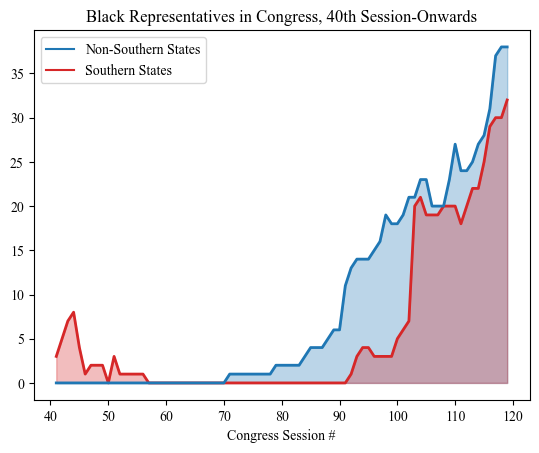

In [64]:
plt.rcParams['font.family'] = 'Times New Roman'
plt.plot(south_cong["Session No"], south_cong["no"], color='tab:red', linestyle='-', marker='', linewidth=2)
plt.plot(non_south_cong["Session No"], non_south_cong["no"], color='tab:blue', linestyle='-', marker='', linewidth=2)
plt.fill_between(non_south_cong["Session No"], non_south_cong["no"], color="tab:blue", alpha=0.3)
plt.fill_between(south_cong["Session No"], south_cong["no"], color="tab:red", alpha=0.3)
plt.title("Black Representatives in Congress, 40th Session-Onwards")
plt.xlabel("Congress Session #")
plt.plot([], [], color='tab:blue',label="Non-Southern States")
plt.plot([], [], color='tab:red', label="Southern States")
plt.legend()